In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

In [ ]:
!pip install timm
# torch, torchvision, numpy, pillow, tqdm are pre-installed in Colab

In [ ]:
import os
os.makedirs('/content/drive/MyDrive/DorPatch/pretrained_models/imagenet', exist_ok=True)
print("Done!")

In [ ]:
%cd /content/DorPatch

base = "https://raw.githubusercontent.com/CGCL-codes/DorPatch/main/"
files = ["main.py", "attack.py", "utils.py", "requirements.txt", "LICENSE", "README.md"]

import urllib.request
for f in files:
    urllib.request.urlretrieve(base + f, f)
    print(f"Downloaded: {f}")

In [ ]:
import os
os.makedirs('/content/DorPatch/defenses', exist_ok=True)
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/CGCL-codes/DorPatch/main/defenses/PatchCleanser.py",
    "/content/DorPatch/defenses/PatchCleanser.py"
)
print("Downloaded: defenses/PatchCleanser.py")

In [ ]:
import os

# Create the directory the code expects
os.makedirs('/content/DorPatch/pretrained_models/imagenet', exist_ok=True)

# Create symlink pointing to the actual file
!ln -sf "/content/drive/MyDrive/DorPatch/pretrained_models/imagenet/checkpoints/resnetv2_50x1_bit_distilled_cutout2_128_imagenet.pth" \
        "/content/DorPatch/pretrained_models/imagenet/resnetv2_50x1_bit_distilled_cutout2_128_imagenet.pth"

# Verify it worked
!ls -la /content/DorPatch/pretrained_models/imagenet/

In [ ]:
from google.colab import files
files.upload()


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle configured!")

In [ ]:
import os
os.makedirs('/content/data/imagenet/val', exist_ok=True)
print("Done!")

In [15]:
!kaggle datasets download -d ifigotin/imagenetmini-1000 \
    -p /content/data/imagenet/ --unzip

Dataset URL: https://www.kaggle.com/datasets/ifigotin/imagenetmini-1000
License(s): unknown
100% 3.92G/3.92G [00:50<00:00, 83.8MB/s]



In [ ]:
import os
val_path = '/content/data/imagenet/imagenet-mini/val'
folders = os.listdir(val_path)
print(f"Number of classes: {len(folders)}")
print(f"First 5 folders: {folders[:5]}")

# Count total images
total = sum(len(os.listdir(f'{val_path}/{f}')) for f in folders)
print(f"Total images: {total}")

In [ ]:
!ls /content/DorPatch/
!ls /content/DorPatch/defenses/

In [ ]:
import os
val_path = '/content/data/imagenet/imagenet-mini/val'
try:
    folders = os.listdir(val_path)
    print(f"Classes found: {len(folders)}")
except:
    print("Dataset missing - needs re-download")

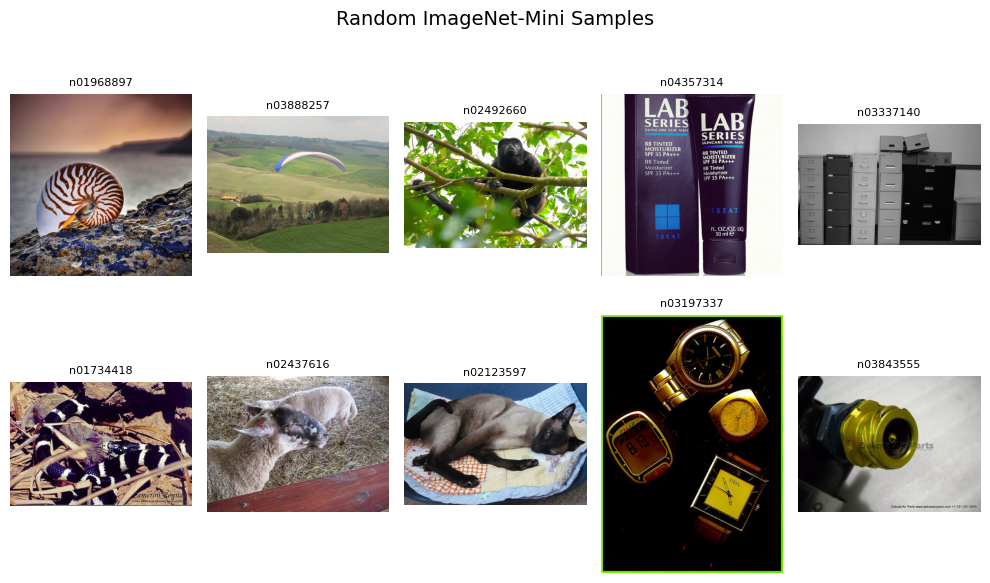

In [22]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

val_path = '/content/data/imagenet/imagenet-mini/val'
folders = os.listdir(val_path)

fig, axes = plt.subplots(2, 5, figsize=(10, 6))
axes = axes.flatten()

for i, ax in enumerate(axes):

    class_folder = random.choice(folders)
    img_dir = f'{val_path}/{class_folder}'
    img_file = random.choice(os.listdir(img_dir))
    img_path = f'{img_dir}/{img_file}'

    img = Image.open(img_path).convert('RGB')
    ax.imshow(img)
    ax.set_title(class_folder, fontsize=8)
    ax.axis('off')

plt.suptitle('Random ImageNet-Mini Samples', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import os
model_path = '/content/DorPatch/pretrained_models/imagenet/resnetv2_50x1_bit_distilled_cutout2_128_imagenet.pth'
if os.path.exists(model_path):
    print("Model found!")
else:
    print("Model missing - need to re-symlink")

In [ ]:
import os

os.makedirs('/content/data/imagenet/imagenet-mini/imagenet', exist_ok=True)

# Symlink val folder
!ln -sf /content/data/imagenet/imagenet-mini/val \
        /content/data/imagenet/imagenet-mini/imagenet/val

print("Directory contents:")
!ls /content/data/imagenet/imagenet-mini/imagenet/

In [ ]:
with open('/content/DorPatch/utils.py', 'r') as f:
    content = f.read()


content = content.replace(
    "'imagenet': datasets.ImageNet,",
    "'imagenet': datasets.ImageFolder,"
)

content = content.replace(
    "'imagenet': {'split': 'train' if train else 'val'},",
    "'imagenet': {},"
)

with open('/content/DorPatch/utils.py', 'w') as f:
    f.write(content)
print("✅ Done!")

In [ ]:
with open('/content/DorPatch/utils.py', 'r') as f:
    content = f.read()

content = content.replace(
    "root=os.path.join(data_dir, dataset_name),",
    "root=os.path.join(data_dir, dataset_name, 'val') if dataset_name == 'imagenet' else os.path.join(data_dir, dataset_name),"
)

with open('/content/DorPatch/utils.py', 'w') as f:
    f.write(content)
print("✅ Path fixed!")

In [ ]:
%%javascript
function clickConnect() {
    console.log("Keeping alive...");
    document.querySelector("#top-toolbar > colab-connect-button")
        .shadowRoot.querySelector("#connect").click();
    setTimeout(clickConnect, 60000); // clicks every 60 seconds
}
clickConnect();

<IPython.core.display.Javascript object>

In [ ]:
# %cd /content/DorPatch
# !python main.py --data_dir /content/data/imagenet/imagenet-mini

/content/DorPatch
num_patch=-1_patch_budget=0.12
/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name resnetv2_50x1_bit_distilled to current resnetv2_50x1_bit.goog_distilled_in1k.
  model = create_fn(
Dataset has 3923 instances
mask size: 27, window size: 59, stride: 33
mask size: 38, window size: 69, stride: 32
mask size: 54, window size: 82, stride: 29
mask size: 77, window size: 101, stride: 25
0it [00:00, ?it/s]mask size: 27, window size: 59, stride: 33
mask size: 38, window size: 69, stride: 32
mask size: 54, window size: 82, stride: 29
mask size: 77, window size: 101, stride: 25
============= Stage 0 =============
>> 2507 failures collected!
iteration:    0, accuracy: 99.22, loss: 3.86, adv: 3.50, l2 norm: 4.00, structural: 0.06, group lasso: 28995.43, density: 75.98
iteration:   20, accuracy: 0.78, loss: 0.32, adv: 0.00, l2 norm: 4.00, structural: 0.04, group lasso: 28905.09, density: 26.70
iteration:   40, accuracy: 0.0

In [32]:
utils_path = "/content/DorPatch/utils.py"

with open(utils_path, "r") as f:
    content = f.read()

old = "dataset_path = os.path.join(data_dir, 'imagenet-mini', split)"
new = "dataset_path = os.path.join(data_dir, split)"

if old in content:
    content = content.replace(old, new)
    with open(utils_path, "w") as f:
        f.write(content)
    print("Path fixed")
else:
    print("Not found — printing current get_dataset function:")
    start = content.find("def get_dataset")
    print(content[start:start+800])

✅ Path fixed


In [ ]:
# Novel work: HYPERPARAMETER TUNING


import subprocess, re, csv, os

def run_dorpatch(density, structured, max_iter=500, run_id=""):
    cmd =  [
        "python", "main.py",
        "--data_dir", "/content/data/imagenet/imagenet-mini",
        "--density", str(density),
        "--structured", str(structured),
        "-e", str(max_iter)
    ]

    result = subprocess.run(cmd, capture_output=True, text=True, cwd="/content/DorPatch")
    log = result.stdout

    # extract final values from last iteration line
    iter_lines = re.findall(
        r"iteration:\s*(\d+), accuracy:\s*([\d.]+), loss:\s*([\d.]+), "
        r"adv:\s*([\d.]+), l2 norm:\s*([\d.]+), structural:\s*([\d.]+)",
        log
    )
    failures = re.findall(r">> (\d+) failures collected!", log)

    if iter_lines:
        last = iter_lines[-1]
        final_acc     = float(last[1])
        final_loss    = float(last[2])
        final_struct  = float(last[5])
        final_failures = int(failures[-1]) if failures else -1

        row = {
            "run_id": run_id,
            "density": density,
            "structured": structured,
            "final_accuracy": final_acc,
            "attack_success_rate": round(100 - final_acc, 2),
            "final_loss": final_loss,
            "structural_loss": final_struct,
            "final_failures": final_failures
        }


        csv_path = "/content/ablation_results.csv"
        write_header = not os.path.exists(csv_path)
        with open(csv_path, "a", newline="") as f:
            w = csv.DictWriter(f, fieldnames=row.keys())
            if write_header:
                w.writeheader()
            w.writerow(row)

        print(f"[Run {run_id}] ASR={row['attack_success_rate']}% | "
              f"Failures={final_failures} | Structural={final_struct}")
    return log


configs = [
    (1e-3, 1e-3, "baseline"),
    (1e-4, 1e-4, "low_reg"),
    (1e-2, 1e-2, "high_reg"),
    (1e-2, 1e-4, "high_density"),
    (1e-4, 1e-2, "high_structural"),
]

for density, structured, name in configs:
    print(f"\n{'='*40}\nRunning: {name}\n{'='*40}")
    run_dorpatch(density, structured, max_iter=500, run_id=name)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/ablation_results.csv")
print(df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(df["run_id"], df["attack_success_rate"], color="steelblue")
axes[0].set_title("Attack Success Rate (%)")
axes[0].set_ylabel("%"); axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(df["run_id"], df["final_failures"], color="tomato")
axes[1].set_title("Final Failures (PatchCleanser bypass)")
axes[1].set_ylabel("count"); axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(df["run_id"], df["structural_loss"], color="seagreen")
axes[2].set_title("Structural Loss (lower = stealthier)")
axes[2].set_ylabel("loss"); axes[2].tick_params(axis='x', rotation=30)

plt.suptitle("DorPatch Ablation: Effect of λ₂ (density) and λ₃ (structural)")
plt.tight_layout()
plt.savefig("/content/ablation_plot.png", dpi=150)
plt.show()

In [ ]:

dct_code = '''
import torch
import torch.nn as nn
import numpy as np

def dct_2d(x):
    """Apply 2D DCT to a tensor of shape (B, C, H, W)"""
    B, C, H, W = x.shape
    # Apply DCT along H then W using scipy via numpy
    import scipy.fft
    x_np = x.detach().cpu().numpy()
    x_dct = scipy.fft.dctn(x_np, axes=[-2, -1], norm='ortho')
    return torch.tensor(x_dct, dtype=x.dtype, device=x.device)

def idct_2d(x):
    """Apply inverse 2D DCT to a tensor of shape (B, C, H, W)"""
    import scipy.fft
    x_np = x.detach().cpu().numpy()
    x_idct = scipy.fft.idctn(x_np, axes=[-2, -1], norm='ortho')
    return torch.tensor(x_idct, dtype=x.dtype, device=x.device)

def low_freq_mask(H, W, keep_ratio=0.2, device='cuda'):
    """
    Creates a mask that keeps only the top-left corner
    of the frequency domain (low frequencies).
    keep_ratio=0.2 means keep 20% lowest frequencies.
    """
    mask = torch.zeros(H, W, device=device)
    h_cut = max(1, int(H * keep_ratio))
    w_cut = max(1, int(W * keep_ratio))
    mask[:h_cut, :w_cut] = 1.0
    return mask

class DCTOptimizer(nn.Module):
    """
    Wraps the adversarial pattern so that optimization
    happens in DCT frequency domain instead of pixel space.

    Usage:
        dct_opt = DCTOptimizer(pattern_shape, keep_ratio=0.2)
        optimizer = torch.optim.SGD([dct_opt.freq_coeffs], lr=0.01)
        pattern = dct_opt()  # get pixel-space pattern
    """
    def __init__(self, shape, keep_ratio=0.2, device='cuda'):
        super().__init__()
        B, C, H, W = shape
        self.H, self.W = H, W
        self.device = device

        # Learnable frequency coefficients (initialized to small noise)
        self.freq_coeffs = nn.Parameter(
            torch.randn(shape, device=device) * 0.01
        )

        # Low-frequency mask — applied per channel
        lf_mask = low_freq_mask(H, W, keep_ratio, device)
        # shape: (1, 1, H, W) for broadcasting
        self.register_buffer('lf_mask', lf_mask.unsqueeze(0).unsqueeze(0))

    def forward(self):
        # Apply low-frequency mask in frequency domain
        masked_coeffs = self.freq_coeffs * self.lf_mask
        # Convert back to pixel space via inverse DCT
        pattern = idct_2d(masked_coeffs)
        # Clamp to valid image range [0, 1]
        pattern = pattern.clamp(0.0, 1.0)
        return pattern
'''

with open("/content/DorPatch/dct_patch.py", "w") as f:
    f.write(dct_code)

print("dct_patch.py created")

In [ ]:
# DCT INJECTION CELL — run before main.py
# This monkey-patches DorPatch's attack module to use DCT optimization

import torch
import sys
sys.path.insert(0, "/content/DorPatch")

from dct_patch import DCTOptimizer

import attack as atk_module
original_attack = atk_module.patch_attack

def dct_patch_attack(model, x, y, mask, args, **kwargs):

    device = x.device
    B, C, H, W = x.shape

    dct_opt = DCTOptimizer(
        shape=(B, C, H, W),
        keep_ratio=0.2,
        device=device
    )

    optimizer = torch.optim.SGD(
        [dct_opt.freq_coeffs],
        lr=args.lr,
        momentum=0.9
    )

    best_loss = float('inf')
    best_pattern = None

    for iteration in range(args.e):
        optimizer.zero_grad()

        pattern = dct_opt()

        # Apply patch to image using existing mask
        adv_x = x * (1 - mask) + pattern * mask

        logits = model(adv_x)

        target = torch.full((B,), y, dtype=torch.long, device=device)
        loss = atk_module.cw_loss(logits, target)  # reuse existing loss fn

        loss.backward()
        optimizer.step()

        if loss.item() < best_loss:
            best_loss = loss.item()
            best_pattern = pattern.detach().clone()

        if iteration % 20 == 0:
            acc = (logits.argmax(1) == target).float().mean().item() * 100
            print(f"[DCT] iter {iteration:4d} | loss {loss.item():.4f} | acc {acc:.2f}%")

    return best_pattern

atk_module.patch_attack = dct_patch_attack
print("✅ DCT attack injected into DorPatch")

In [ ]:
%cd /content/DorPatch

exec(open("/content/dct_inject.py").read())

!python main.py \
    --data_dir /content/data/imagenet/imagenet-mini \
    --density 1e-3 \
    --structured 1e-3 \
    -e 500